## Problem 7.2 - Meeting K-Means

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import make_moons

In [2]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

### a) clustering with KMeans from sklearn.cluster

In [3]:
# generate data
X, y = make_blobs(n_samples = 100, centers = 4, n_features = 2, cluster_std = 1, random_state = 2)

In [4]:
# fit KMeans model
kmeans = KMeans(n_clusters = 4, random_state = 2)
kmeans.fit(X)
y_pred = kmeans.predict(X)

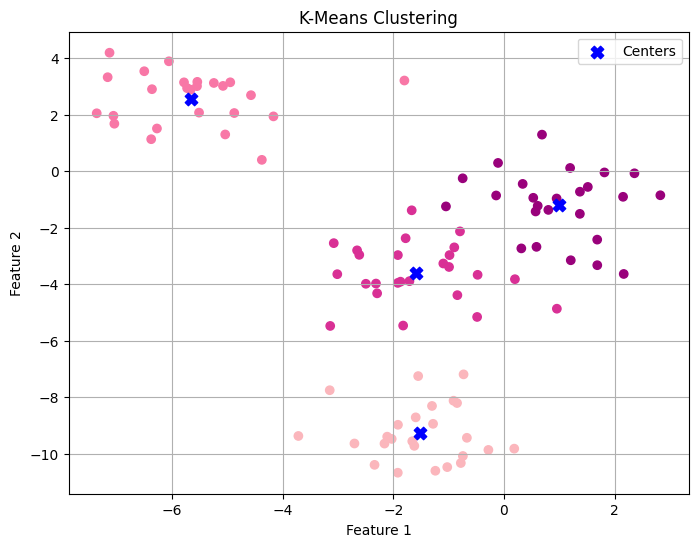

In [5]:
#plot the results
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c = y_pred, cmap = truncated_RdPu, marker = 'o')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'blue', marker = 'X', s = 80, label = 'Centers')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

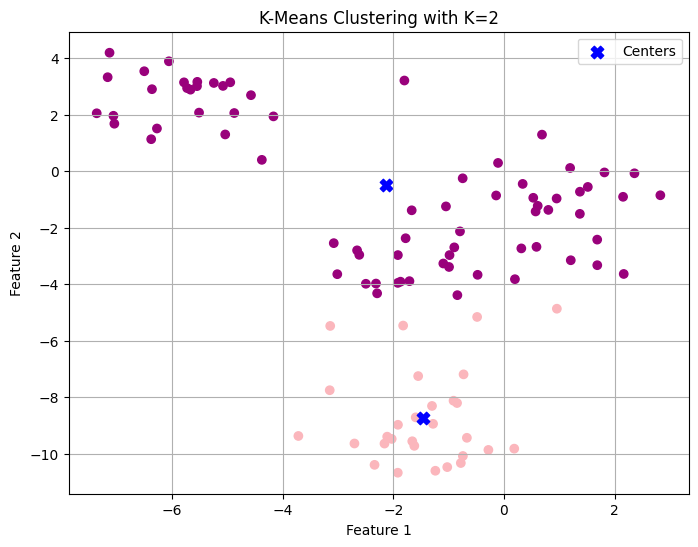

In [ ]:
# what if we change the number of clusters to K = 2
kmeans_2 = KMeans(n_clusters = 2, random_state = 2)
kmeans_2.fit(X)
y_pred_2 = kmeans_2.predict(X)

#plot the results
plt.figure(figsize = (8,6))
plt.scatter(X[:, 0], X[:, 1], c = y_pred_2, cmap = truncated_RdPu, marker = 'o')
plt.scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], c = 'blue', marker = 'X', s = 80, label = 'Centers')
plt.title('K-Means Clustering with K = 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

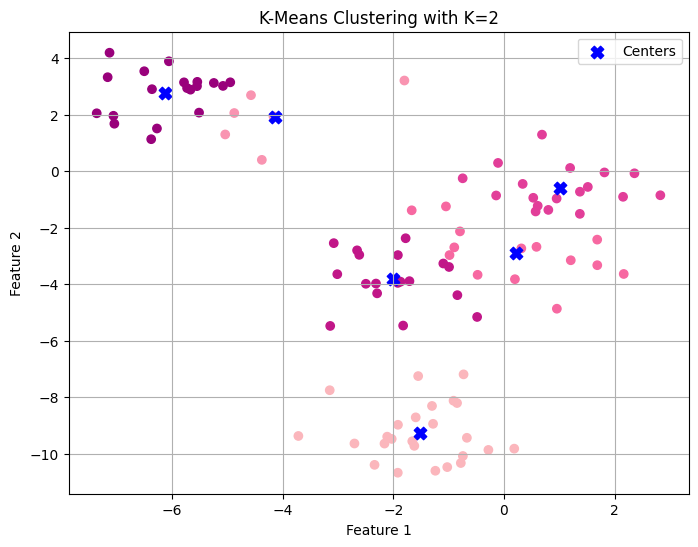

In [ ]:
# what if we change the number of clusters to K = 2
kmeans_2 = KMeans(n_clusters = 6, random_state = 2)
kmeans_2.fit(X)
y_pred_2 = kmeans_2.predict(X)

#plot the results
plt.figure(figsize = (8,6))
plt.scatter(X[:, 0], X[:, 1], c = y_pred_2, cmap = truncated_RdPu, marker = 'o')
plt.scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], c = 'blue', marker = 'X', s = 80, label = 'Centers')
plt.title('K-Means Clustering with K = 6')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

#### Observations:  
- When we reduce K to 2 we observe that some clusters from before merge together into one big cluster. 
- Since we created our data with four center we see, that the new cluster are spread out much wider.  
- On the other hand a larger number of clusters (K = 6) leads to split natural clusters in the data unnecessarily. Bigger clusters are split into smaller bits.

### b) Observations for K-Means with K = 2 and make_moons

In [8]:
# generate data with make_moons
X,y = make_moons(n_samples = 200, noise = 0.05, random_state = 0)

In [9]:
# fit the KMeans model
kmeans_moon = KMeans(n_clusters = 2, random_state = 0)
kmeans_moon.fit(X)
y_pred_moon = kmeans_moon.predict(X)


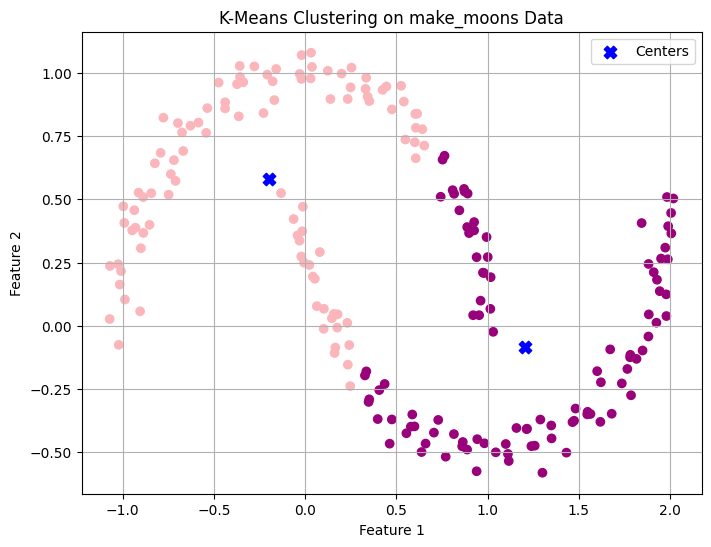

In [10]:
# plot the results
plt.figure(figsize = (8,6))
plt.scatter(X[:, 0], X[:,1], c = y_pred_moon, cmap = truncated_RdPu, marker = 'o')
plt.scatter(kmeans_moon.cluster_centers_[:, 0], kmeans_moon.cluster_centers_[:, 1], c = 'blue', marker = 'X', s = 80, label = 'Centers')
plt.title('K-Means Clustering on make_moons Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()  

### Observations:  
- Make_moons creates data with two features and binary labels (0,1) that indicate to which moon a datapoint belongs to.
- In our example the two moon shapes slight overlap.
- We find the centers on the tips of our moon shaped data.
- The data gets clustered rather circle shaped which does not follow our original labelig shapes.
- This indicates that clustering works better for datapoints that are spherically clustered. 

### c) Optional: Create a K-Means function from scratch

In [11]:
def my_kmeans(X, n_clusters, max_iter = 100, epsilon = 1e-4):

    # step 0: choose K random observations as initial cluster centers
    np.random.seed(42)
    random_indices = np.random.choice(X.shape[0], n_clusters, replace = False)
    centers = X[random_indices]

    # iteratively we do step 1 and step 2
    for i in range(max_iter):
        # step 1: assign data points to the nearest cluster center
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis = 2)
        labels = np.argmin(distances, axis = 1)

        # step 2: compute mean of assigned points to update cluste centers
        new_centers = np.array([X[labels == k].mean(axis = 0) for k in range(n_clusters)])

        # step 3: check for convergence
        if np.linalg.norm(new_centers - centers) < epsilon:
            print("Converged after {} iterations".format(i+1))
            break

        centers = new_centers
    
    return centers, labels

Converged after 3 iterations


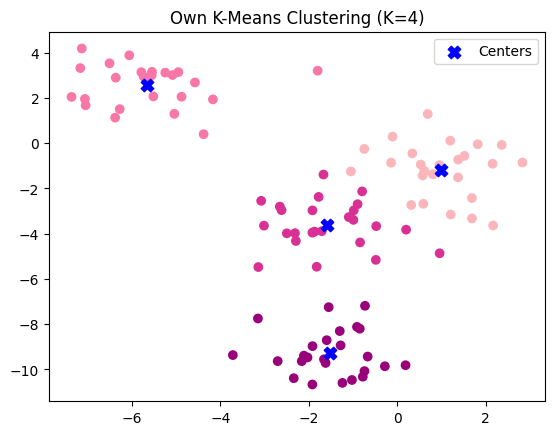

In [12]:
# test own K-Means function
X, y = make_blobs(n_samples = 100, centers = 4, n_features = 2, cluster_std = 1, random_state = 2)

centers, labels = my_kmeans(X, n_clusters = 4)
plt.scatter(X[:, 0], X[:, 1], c = labels, cmap = truncated_RdPu)
plt.scatter(centers[:, 0], centers[:, 1], c = 'blue', s = 80, marker = 'X', label = 'Centers')
plt.title("Own K-Means Clustering (K=4)")
plt.legend()
plt.show()

We see that we get similar results to the built-in function.